# 该脚本用于删除研究区域外的数据，包含以下功能：
### 1. 对研究区域进行旋转
### 2. 删除研究区域外的地震与台站

In [1]:
# 载入 TomoATT 数据处理函数
# import sys
# sys.path.append('../utils')
# import functions_for_data as ffd
import pytomoatt as pta
import shutil

In [2]:
# 文件准备
import os
os.makedirs('figs', exist_ok=True)

output_dir = "traveltime_data"

fname = f"{output_dir}/src_rec_Turkey.tar.gz"
shutil.unpack_archive(fname, output_dir)

# 1. 读取数据并画图

2026-08-03 00:28:39,581 [SrcRec] WARNING: Found conflicting coordinates/elevations for 17 receiver(s): CSS, GAZ, BZK, HNTI, BNN, BR, KOZT, MMC, MMB, MMA, AKK, NATI, GEM, ARPR, ZRT, HULT, CY.


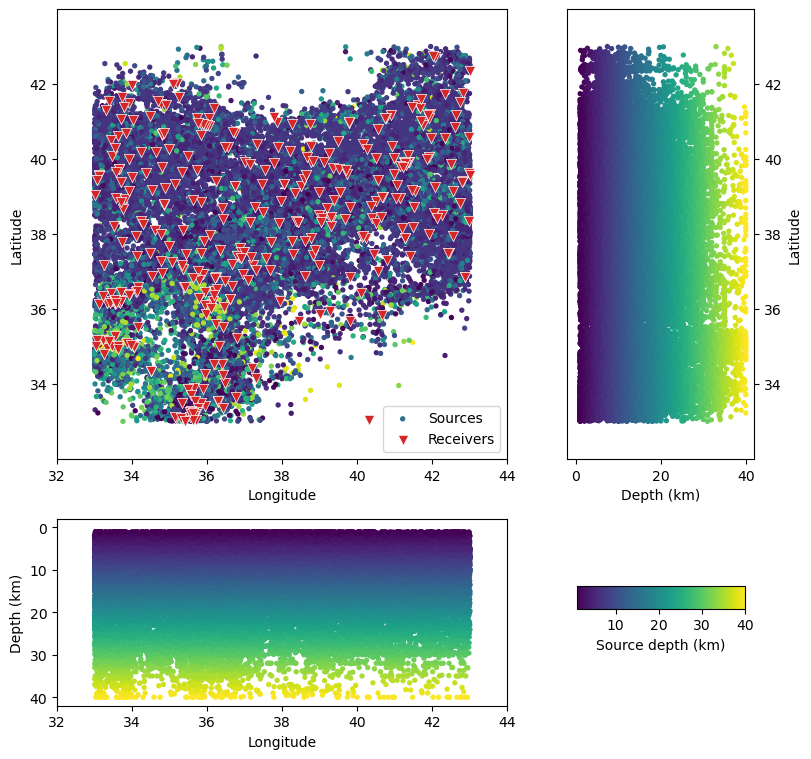

In [3]:
# 读取数据
# [ev_info_obs, st_info_obs] = ffd.read_src_rec_file(fname)
sr = pta.SrcRec.read(f"{output_dir}/src_rec_Turkey.dat")

# 数据画图（可选） fname = None 可以不保存图片
sr.plot(color_by='depth', fname="figs/step1_original_data.png");


# 2. 选定研究区域
1. 研究区域是 一个以 `(central_lon, central_lat)` 为中心的矩形，
2. y方向范围为 `[central_lat+lat1, central_lat+lat2]`， x方向范围为 `[central_lon+lon1, central_lon+lon2]`
3. 然后对研究区域进行顺时针旋转 `rotation_angle` 度

In [4]:
central_lat = 37.0      # 旋转中心纬度
central_lon = 37.0      # 旋转中心经度
rotation_angle = 45.0   # 顺时针旋转角度

lat1 = -2.0;    lat2 = 3.0;     # 研究区域 y 方向范围
lon1 = -1.3;    lon2 = 1.3;     # 研究区域 x 方向范围
dep1 =  0.5;    dep2 = 40.0;    # 研究区域深度方向范围

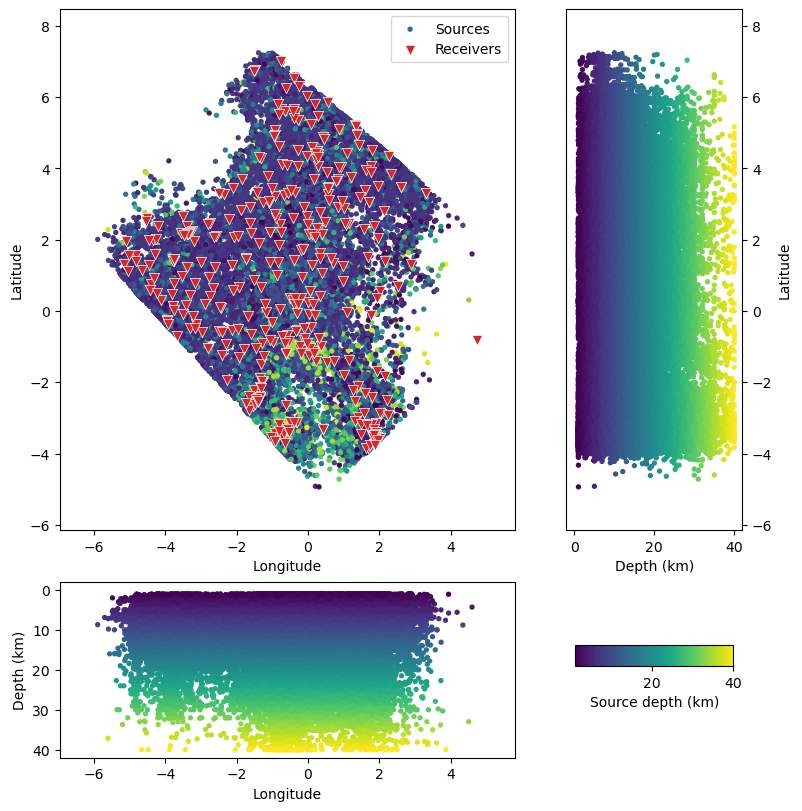

In [5]:
# 如果研究区域是规则经纬度范围，无需旋转的话，可省略该步骤。

# 首先对所有地震与台站坐标进行旋转。满足：
# 0. 复制`sr`实例到`sr_rot`，避免修改原始数据。
# 1. 坐标原始地理位置 (central_lon,central_lat) 将变为经纬度 (0,0)。
# 2. 逆时针旋转 rotation_angle 角度。（PS：对数据逆时针旋转等价于研究区域顺时针选择）
sr_rot = sr.copy()
sr_rot.rotate(central_lon, central_lat, rotation_angle)

# 数据画图（可选）
sr_rot.plot(color_by='depth', fname="figs/step1_rotated_data.png");


2026-08-03 00:28:55,284 [SrcRec] INFO: src_points before selection: 144571
2026-08-03 00:28:55,284 [SrcRec] INFO: rec_points before selection: 1413256
2026-08-03 00:28:55,425 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-03 00:28:55,574 [SrcRec] INFO: Removed 777 duplicate receivers in rec_points
2026-08-03 00:28:55,608 [SrcRec] INFO: src_points after selection: (66337, 8)
2026-08-03 00:28:55,608 [SrcRec] INFO: rec_points after selection: (489987, 9)
2026-08-03 00:28:55,608 [SrcRec] INFO: src_points before selection: (66337, 8)
2026-08-03 00:28:55,608 [SrcRec] INFO: rec_points before selection: (489987, 9)
2026-08-03 00:28:55,700 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-03 00:28:55,862 [SrcRec] INFO: src_points after selection: (66337, 8)
2026-08-03 00:28:55,863 [SrcRec] INFO: rec_points after selection: (489987, 9)


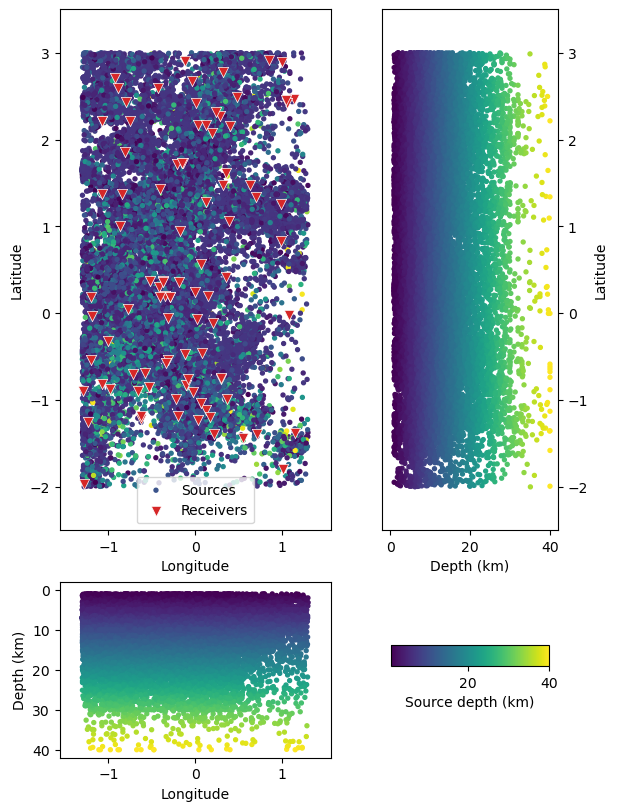

In [6]:
# 删除研究区域外的地震
sr_rot.select_by_box_region([lon1, lon2, lat1, lat2])

# 删除较大的深度数据
sr_rot.select_by_depth([dep1, dep2])

# 数据画图（可选）
sr_rot.plot(color_by='depth', fname="figs/step1_rotated_indom_data.png");

# 3. 数据输出

In [7]:
# 将数据输出到指定目录
out_path = "output_data"
os.makedirs(out_path, exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = f"{out_path}/step1_src_rec_indom.dat"
sr_rot.write(out_fname)

Writing src_rec file: 100%|██████████| 66337/66337 [00:21<00:00, 3117.01it/s]


# 4. （可选）还原到现实坐标，观察数据分布

Writing src_rec file: 100%|██████████| 66337/66337 [00:21<00:00, 3030.21it/s]


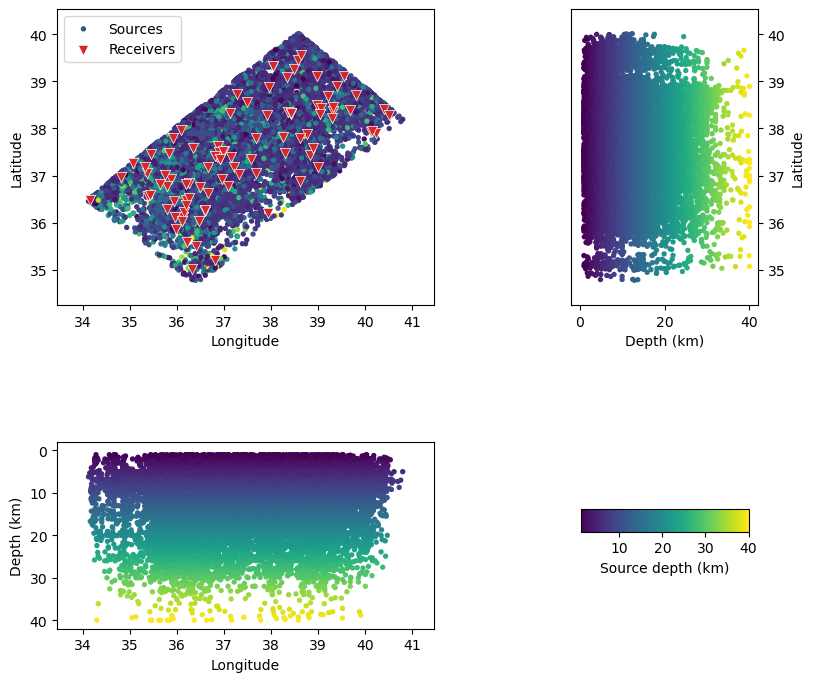

In [8]:
# 将数据旋转回原始地理位置
sr_rot.rotate(central_lon, central_lat, rotation_angle, reverse=True)

# 数据画图 （可选）
sr_rot.plot(color_by='depth', fname="figs/step1_indom_data.png")
# ffd.fig_ev_st_distribution_dep(ev_indom, st_indom, fname = "figs/step1_indom_data.png")

# 真实地震列表
out_fname_ev = f"{out_path}/step1_ev_list.dat"
sr_rot.write_sources(out_fname_ev)

# 真实台站列表
out_fname_st = f"{out_path}/step1_st_list.dat"
sr_rot.write_receivers(out_fname_st)

# 真实到时数据
out_fname_tt = f"{out_path}/step1_src_rec_data_norot.dat"
sr_rot.write(out_fname_tt)